<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Logistic Regression Practice

---

# Titanic
On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing over 1,500 of its 2,224 passengers and crew. Survival wasn't random — factors like class, sex, and age all played a role in who made it into a lifeboat.

You will be predicting `Survived`: whether a passenger survived (1) or did not (0), using their ticket and demographic information.

# Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, precision_score, f1_score

### 1. Load the data

Read in the `titanic.csv` data.

In [2]:
# Load the data
df = pd.read_csv('data/titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Drop columns that won’t help the model

> `PassengerId` is just a row ID, `Name` and `Ticket` are high-cardinality free text, and `Cabin` is missing for the vast majority of passengers.

In [3]:
# Drop columns that won't help the model
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 3. Handle missing values

> Check for missing values. `Age` and `Embarked` both have null values, fill them in (median for `Age` and the most common value for `Embarked`).

In [4]:
# Handle missing values: median for Age, most common value for Embarked
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isna().sum()


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# Modeling

### 4. Set up your target and features, and split into training and testing sets

Set `Survived` as your target, `y`. Everything else remaining is your feature matrix, `X`.

In [5]:
# Set up target and features, split into training and testing sets
y = df['Survived']
X = df.drop(columns='Survived')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


### 5. Establish a baseline

What accuracy would you get by always predicting the majority class? This is the number your model needs to beat.

In [6]:
# Baseline: always predict the majority class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

baseline_acc = dummy.score(X_test, y_test)
print(f'Baseline accuracy: {baseline_acc:.3f}')


Baseline accuracy: 0.601


### 6. Build a `Pipeline` with a `ColumnTransformer`

> Use a `ColumnTransformer` to scale your numeric features and encode your categorical features. Then chain it into a `Pipeline`.

In [7]:
# Build a Pipeline with a ColumnTransformer
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

preprocessing = ColumnTransformer([
    ('scaler', StandardScaler(), num_cols),
    ('onehotencoder', OneHotEncoder(), cat_cols),
])

pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(max_iter=1000)),
])


/tmp/ipykernel_7009/3408045344.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


### 7. Fit your pipeline and evaluate train vs. test accuracy

Is there a meaningful gap between train and test performance? Is this model better than the null model?

In [8]:
# Fit the pipeline and evaluate train vs. test accuracy
pipeline.fit(X_train, y_train)

train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)

print(f'Train accuracy: {train_acc:.3f}')
print(f'Test accuracy: {test_acc:.3f}')
print(f'Baseline accuracy: {baseline_acc:.3f}')


Train accuracy: 0.799
Test accuracy: 0.807
Baseline accuracy: 0.601


### 8. Confusion matrix

> Generate a confusion matrix for your model's predictions on the test set. Which type of mistake is your model making more (predicting survival for someone who didn't, or the reverse?)

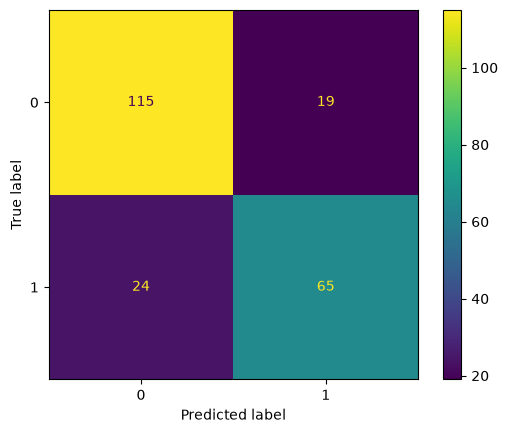

In [9]:
# Confusion matrix for test set predictions
y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()


### 9. Classification report

> Print a classification report (precision, recall, f1-score) for the test set.

In [10]:
# Classification report for test set predictions
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.86      0.84       134
           1       0.77      0.73      0.75        89

    accuracy                           0.81       223
   macro avg       0.80      0.79      0.80       223
weighted avg       0.81      0.81      0.81       223



# Interpretation & Predictions

### 10. Pull out your feature names and coefficients

> Your `ColumnTransformer` renames and reorders your columns when it transforms `X`, the numeric columns keep their original names, but the one-hot encoded categorical columns get new names like `Sex_male`. Before you can interpret any coefficient, you need to know which coefficient belongs to which feature.
>
> 1. Get the one-hot encoded feature names out of your fitted `ColumnTransformer` using:
>
>    `.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)`.
> 
> 2. Combine these with your numeric column names, **in the same order your `ColumnTransformer` outputs them** (e.g. numeric columns first, then categorical).
> 
> 3. Pair these feature names with your fitted model's `.coef_[0]` values in a `pandas.Series` (feature names as the index), so you can look up any coefficient by name.

In [11]:
# Pull out feature names and coefficients
encoded_names = pipeline.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)
feature_names = list(num_cols) + list(encoded_names)

coefficients = pd.Series(pipeline.named_steps['model'].coef_[0], index=feature_names)
coefficients


Pclass       -0.780135
Age          -0.424124
SibSp        -0.315537
Parch        -0.099785
Fare          0.168824
Sex_female    1.285944
Sex_male     -1.335821
Embarked_C    0.185090
Embarked_Q    0.020549
Embarked_S   -0.255517
dtype: float64

### 11. Interpret one coefficient

> Pick one feature and interpret its coefficient. Convert it from log-odds into an odds ratio (`np.exp(coef)`), and explain in a sentence what it does to the odds of survival.

In [12]:
# Interpret one coefficient: Sex_male as an odds ratio
coef = coefficients['Sex_male']
odds_ratio = np.exp(coef)

print(f'Coefficient for Sex_male: {coef:.3f}')
print(f'Odds ratio: {odds_ratio:.3f}')
print(f'Being male multiplies the odds of survival by {odds_ratio:.3f}, so survival is much less likely for males.')


Coefficient for Sex_male: -1.336
Odds ratio: 0.263
Being male multiplies the odds of survival by 0.263, so survival is much less likely for males.


### 12. Generate predictions and predicted probabilities

> Use your model to generate `.predict()` and `.predict_proba()` on the test set. Pick one test observation and explain, in a sentence, what its predicted probability means.

In [13]:
# Generate predictions and predicted probabilities
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

print('Predicted classes (first 10):', y_pred[:10])
print('Predicted probabilities (first 5):')
print(y_proba[:5])
print(f'\nFirst test passenger has a {y_proba[0, 1]:.1%} predicted probability of surviving.')


Predicted classes (first 10): [0 0 0 1 1 1 1 0 1 1]
Predicted probabilities (first 5):
[[0.88677588 0.11322412]
 [0.78115487 0.21884513]
 [0.86647105 0.13352895]
 [0.10790032 0.89209968]
 [0.24374134 0.75625866]]

First test passenger has a 11.3% predicted probability of surviving.


### 12. Try a different threshold

> `.predict()` uses a default threshold of 0.5 on `.predict_proba()` to decide the class. Try lowering it and recompute the confusion matrix and classification report at this new threshold. What trade-off do you see between precision and recall?

In [14]:
# Try a different threshold (0.4 instead of 0.5)
threshold = 0.4
y_pred_40 = (y_proba[:, 1] >= threshold).astype(int)

print(f'Confusion matrix at threshold {threshold}:')
print(confusion_matrix(y_test, y_pred_40))
print()
print(f'Classification report at threshold {threshold}:')
print(classification_report(y_test, y_pred_40))


Confusion matrix at threshold 0.4:
[[106  28]
 [ 19  70]]

Classification report at threshold 0.4:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       134
           1       0.71      0.79      0.75        89

    accuracy                           0.79       223
   macro avg       0.78      0.79      0.78       223
weighted avg       0.79      0.79      0.79       223



### 13. Write a function to print classification metrics with explanations

> Write a function `print_classification_metrics(y_true, y_pred)` that calculates **accuracy**, **recall/sensitivity**, **precision**, **specificity**, and **F1 score**, and prints each metric alongside a clear explanation. Then call your function on your model's test set predictions.
>
> Use the confusion matrix layout below as your reference for which cells (`TP`, `TN`, `FP`, `FN`) each metric is built from.

**Accuracy** — Overall, how often is the classifier correct?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Accuracy} = \frac{TP + TN}{Total}$$

**Recall / Sensitivity / True Positive Rate (TPR)** — Among all passengers who actually survived, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Recall} = \frac{TP}{TP + FN}$$

**Precision** — Among all passengers predicted to survive, what proportion actually did?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Precision} = \frac{TP}{TP + FP}$$

**Specificity / True Negative Rate (TNR)** — Among all passengers who did not actually survive, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center">TP</td>
</tr>
</table>

$$\textbf{Specificity} = \frac{TN}{TN + FP}$$

**$F_1$ score** — The balance between precision and recall.

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$


In [15]:
# Function to print classification metrics with explanations
def print_classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    specificity = tn / (tn + fp)
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f'Accuracy:   {accuracy:.3f}  — Overall, how often is the classifier correct?')
    print(f'Recall:     {recall:.3f}  — Among all passengers who actually survived, what proportion did we correctly detect?')
    print(f'Precision:  {precision:.3f}  — Among all passengers predicted to survive, what proportion actually did?')
    print(f'Specificity: {specificity:.3f}  — Among all passengers who did not actually survive, what proportion did we correctly detect?')
    print(f'F1 score:   {f1:.3f}  — The balance between precision and recall.')

print_classification_metrics(y_test, y_pred)


Accuracy:   0.807  — Overall, how often is the classifier correct?
Recall:     0.730  — Among all passengers who actually survived, what proportion did we correctly detect?
Precision:  0.774  — Among all passengers predicted to survive, what proportion actually did?
Specificity: 0.858  — Among all passengers who did not actually survive, what proportion did we correctly detect?
F1 score:   0.751  — The balance between precision and recall.
